In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df= pd.read_csv("SVMtrain.csv")
df

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,Male,22.0,1,0,7.2500,3
1,2,1,1,female,38.0,1,0,71.2833,1
2,3,1,3,female,26.0,0,0,7.9250,3
3,4,1,1,female,35.0,1,0,53.1000,3
4,5,0,3,Male,35.0,0,0,8.0500,3
...,...,...,...,...,...,...,...,...,...
884,887,0,2,Male,27.0,0,0,13.0000,3
885,888,1,1,female,19.0,0,0,30.0000,3
886,889,0,3,female,60.0,1,2,23.4500,3
887,890,1,1,Male,26.0,0,0,30.0000,1


In [20]:
df.drop('Sex', axis=1, inplace=True)

In [21]:
df

,Survived,Pclass,Age,SibSp,Parch,Fare,Embarked
0,0,3,22.0,1,0,7.2500,3
1,1,1,38.0,1,0,71.2833,1
2,1,3,26.0,0,0,7.9250,3
3,1,1,35.0,1,0,53.1000,3
4,0,3,35.0,0,0,8.0500,3
...,...,...,...,...,...,...,...
884,0,2,27.0,0,0,13.0000,3
885,1,1,19.0,0,0,30.0000,3
886,0,3,60.0,1,2,23.4500,3
887,1,1,26.0,0,0,30.0000,1


In [22]:
x=df.iloc[:,:-1]
y= df['Survived']

In [24]:
x.shape

(889, 6)

In [26]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test= train_test_split(x , y, test_size=0.2, random_state=42)

In [27]:
x_train.shape

(711, 6)

In [43]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

model= AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=100,algorithm='SAMME', random_state=42)
model.fit(x_train, y_train)

AdaBoostClassifier(algorithm='SAMME',
                   estimator=DecisionTreeClassifier(max_depth=1),
                   n_estimators=100, random_state=42)

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier

# Split data
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# Train model
model = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                           n_estimators=100,
                           algorithm='SAMME',
                           random_state=42)
model.fit(x_train, y_train)

# Prediction (IMPORTANT LINE)
y_pred = model.predict(x_test)

print(y_pred)

[0 1 1 0 1 1 0 0 1 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 1 1 0 0 0 0 1
 1 0 0 0 0 0 0 1 1 0 0 0 1 1 1 0 0 1 1 0 0 0 0 1 0 1 0 1 0 0 0 1 1 0 0 0 1
 1 1 0 0 0 0 0 1 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 1 1 1 0 0
 1 0 1 0 0 0 0 1 0 1 1 0 0 1 1 0 1 0 0 1 0 0 0 1 1 0 1 0 1 1 0 1 0 1 1 0 1
 0 0 0 1 0 1 0 1 0 0 0 1 1 1 1 0 0 0 1 0 0 1 0 1 0 0 0 1 1 1]


Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
R2 Score : 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       109
           1       1.00      1.00      1.00        69

    accuracy                           1.00       178
   macro avg       1.00      1.00      1.00       178
weighted avg       1.00      1.00      1.00       178



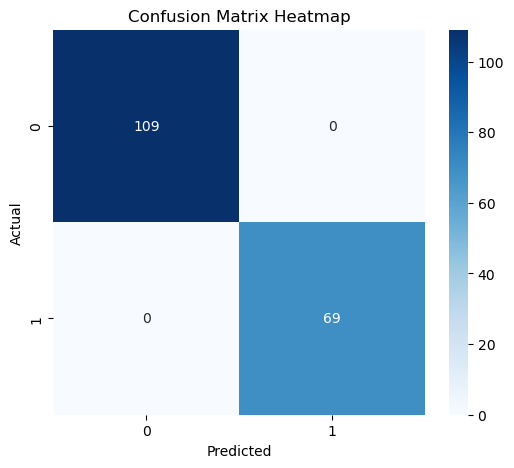

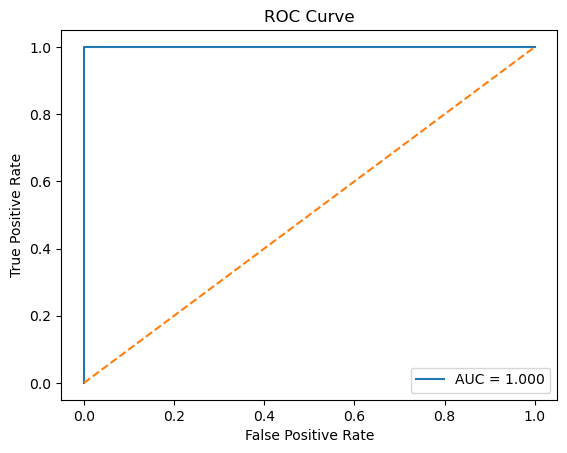

In [45]:
# ===============================
# Import Metrics
# ===============================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    r2_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# Predictions
# ===============================
y_pred = model.predict(x_test)

# Probability needed for ROC
y_prob = model.predict_proba(x_test)[:,1]

# ===============================
# Basic Metrics
# ===============================
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("R2 Score :", r2_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ===============================
# Confusion Matrix Heatmap
# ===============================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ===============================
# ROC Curve
# ===============================
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()